# III. Medidas Descriptivas y IV. Análisis de Correlación
**Dataset:** Registro Nacional de Personas Desaparecidas y No Localizadas (RNPDNO)  

---

## Introducción
En este notebook se lleva a cabo el Análisis Exploratorio de Datos (EDA) cuantitativo y cualitativo. El objetivo es caracterizar a la población desaparecida mediante medidas de tendencia central, dispersión y forma, así como identificar patrones de concentración geográfica y relaciones entre las variables principales (Edad, Sexo y Entidad).

Este análisis se realiza sobre el dataset previamente limpiado y normalizado, asegurando la integridad estadística de los resultados.

Media: 31.64 | Mediana: 29.0 | Moda: 16.0 | Desv. Estándar: 15.18


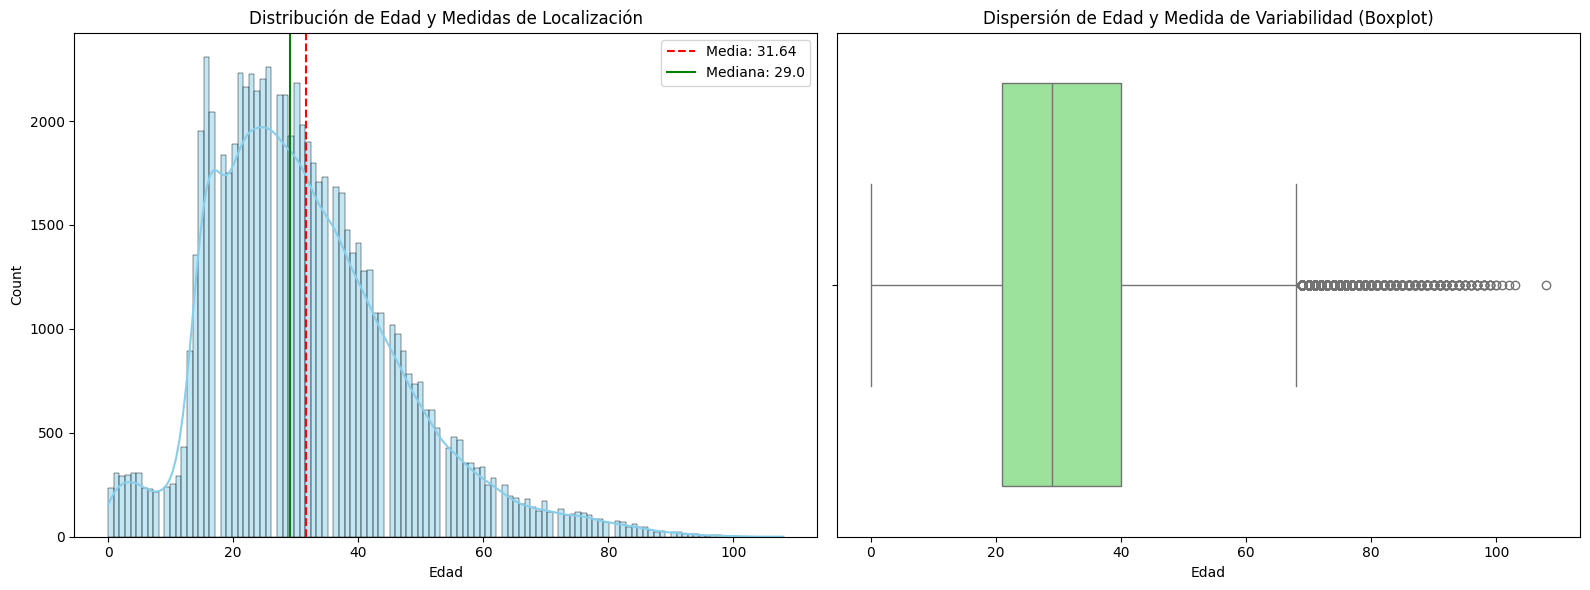

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el dataset que ya fue procesado por el rol de Arquitecto de Datos
df = pd.read_csv('RNPDNO_limpio.csv')

# 2. Cálculo de medidas de tendencia central (Localización)
media = df['Edad'].mean()        # Calcula el promedio aritmético de las edades
mediana = df['Edad'].median()    # Encuentra el valor central (el percentil 50)
moda = df['Edad'].mode()[0]      # Obtiene el valor con mayor frecuencia (la edad más común)

# 3. Cálculo de medida de dispersión (Variabilidad)
std_dev = df['Edad'].std()       # Calcula la desviación estándar (qué tanto se alejan los datos del promedio)

# Imprimir resultados numéricos con 2 decimales para precisión estadística
print(f"Media: {media:.2f} | Mediana: {mediana} | Moda: {moda} | Desv. Estándar: {std_dev:.2f}")

# 4. Creación de la estructura de visualización (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subgráfica 1: Histograma para observar la forma de la distribución (Localización)
sns.histplot(df['Edad'].dropna(), kde=True, color='skyblue', ax=axes[0])
axes[0].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')   # Línea de media
axes[0].axvline(mediana, color='green', label=f'Mediana: {mediana}')              # Línea de mediana
axes[0].set_title('Distribución de Edad y Medidas de Localización')
axes[0].legend() # Mostrar el cuadro de etiquetas de las líneas

# Subgráfica 2: Boxplot para identificar dispersión y valores atípicos (Variabilidad)
sns.boxplot(x=df['Edad'].dropna(), color='lightgreen', ax=axes[1])
axes[1].set_title('Dispersión de Edad y Medida de Variabilidad (Boxplot)')

plt.tight_layout() # Ajusta los espacios para evitar que los textos se encimen
plt.show()         # Despliega las gráficas terminadas

### Interpretación de Localización y Variabilidad
El análisis de las medidas de tendencia central revela que, aunque la edad promedio de desaparición es de **31.64 años**, la **moda se ubica en los 16 años**. Este hallazgo es fundamental: indica que el fenómeno impacta con mayor frecuencia a la población adolescente, un sector de alta vulnerabilidad.

Por otro lado, la desviación estándar de **15.18 años** y la presencia de múltiples valores atípicos (outliers) en el extremo superior del boxplot demuestran que, si bien hay un foco en jóvenes, el problema presenta una alta dispersión que alcanza a personas de la tercera edad, evidenciando que ninguna etapa de la vida está exenta de este riesgo en el contexto actual del país.

El Top 10 de estados concentra el 71.05% de los casos totales.


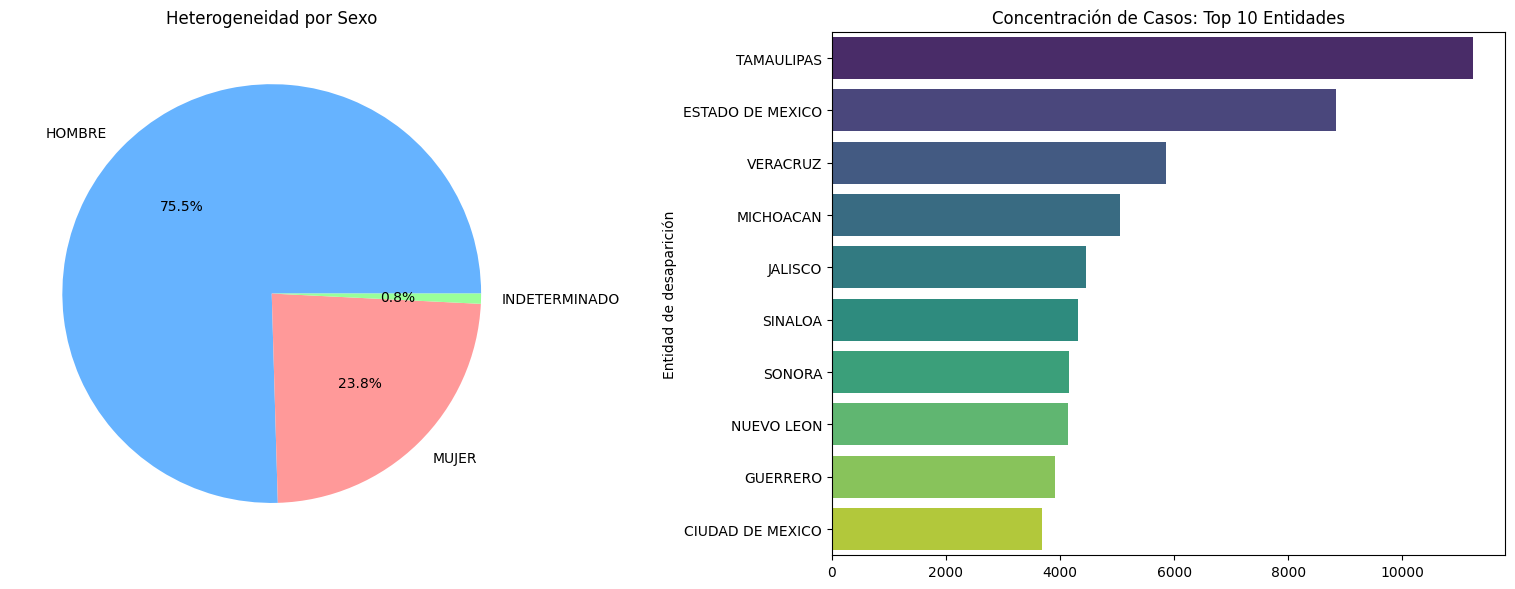

In [15]:
# 1. Análisis de Heterogeneidad (Distribución por Sexo)
# normalize=True convierte las frecuencias en porcentajes (0 a 1)
dist_sexo = df['Sexo'].value_counts(normalize=True) * 100

# 2. Análisis de Concentración (Top 10 Entidades Federativas)
# Seleccionamos solo las 10 entidades con más registros para evitar saturación visual
top_10_entidades = df['Entidad de desaparición'].value_counts().head(10)

# Cálculo del peso estadístico del Top 10 respecto al total
pct_top_10 = (top_10_entidades.sum() / len(df)) * 100
print(f"El Top 10 de estados concentra el {pct_top_10:.2f}% de los casos totales.")

# 3. Creación de visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Pastel: Ideal para mostrar heterogeneidad en variables con pocas categorías
axes[0].pie(dist_sexo, labels=dist_sexo.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999','#99ff99'])
axes[0].set_title('Heterogeneidad por Sexo')

# Gráfico de Barras: Ideal para mostrar concentración de frecuencias
# hue y legend=False se usan para cumplir con las normas actuales de la librería Seaborn
sns.barplot(x=top_10_entidades.values, y=top_10_entidades.index, hue=top_10_entidades.index, palette='viridis', legend=False, ax=axes[1])
axes[1].set_title('Concentración de Casos: Top 10 Entidades')

plt.tight_layout()
plt.show()

### Interpretación de Heterogeneidad y Concentración
Al analizar la distribución por sexo, se observa una **baja heterogeneidad**, dado que existe una marcada concentración de casos en hombres (**75.5%**), lo que permite establecer un perfil de género predominante en los reportes de este dataset.

En términos geográficos, los datos muestran una **altísima concentración**: tan solo **10 entidades federativas acumulan el 71% del total de casos**, con Tamaulipas y el Estado de México a la cabeza. Esto confirma que la desaparición de personas en México no es un fenómeno distribuido de manera uniforme en el territorio, sino que se focaliza violentamente en regiones con dinámicas de inseguridad específicas.

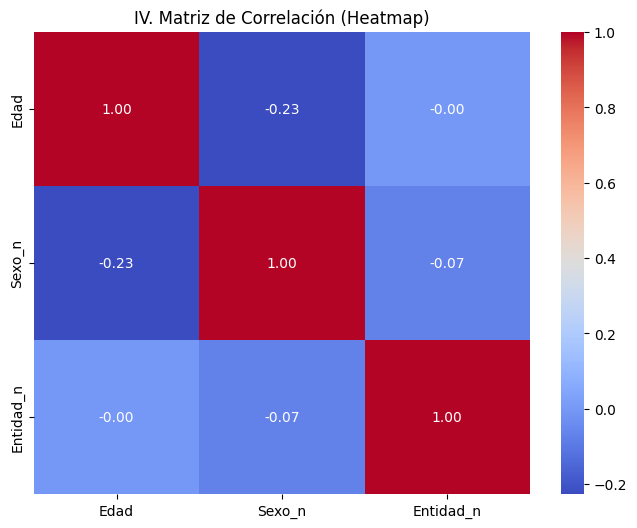

In [14]:
# 1. Preparación de datos (Feature Encoding)
# Creamos una copia del dataframe original para no afectar los datos base
df_corr = df[['Edad', 'Sexo', 'Entidad de desaparición']].copy()

# Convertimos las variables categóricas (texto) en códigos numéricos para poder calcular la correlación de Pearson
df_corr['Sexo_n'] = df_corr['Sexo'].astype('category').cat.codes
df_corr['Entidad_n'] = df_corr['Entidad de desaparición'].astype('category').cat.codes

# 2. Generación de la Matriz de Correlación
# Solo calculamos la correlación entre las columnas numéricas relevantes
matriz = df_corr[['Edad', 'Sexo_n', 'Entidad_n']].corr()

# 3. Visualización mediante un Heatmap (Mapa de calor)
plt.figure(figsize=(8, 6))
# annot=True coloca los valores numéricos dentro de los cuadros
# cmap='coolwarm' usa azul para correlaciones negativas y rojo para positivas
sns.heatmap(matriz, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('IV. Matriz de Correlación (Heatmap)')

plt.show()

### Análisis de Correlación (Sección IV)
La matriz de correlación permite identificar la fuerza de asociación entre las variables clave del estudio:

* **Correlación más fuerte:** Se presenta entre las variables **Edad y Sexo (-0.23)**. Aunque se considera una correlación débil en términos estadísticos absolutos, es la más significativa del modelo, sugiriendo una relación leve entre el género de la víctima y el rango de edad en el que ocurre la desaparición.
* **Correlación más débil:** Se observa entre **Edad y Entidad Federativa (-0.00)**. El valor cercano a cero indica una independencia estadística casi total; esto implica que el patrón de edades de las personas desaparecidas es constante y se repite de manera casi idéntica en cualquier estado de la República, independientemente de la ubicación geográfica.